In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv("/Bank Customer Churn Prediction.csv")

In [ ]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [ ]:
df.isnull()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
y=df['churn']

In [ ]:
x=df.drop('churn',axis=1)

In [ ]:
df.shape

(10000, 12)

In [ ]:

le = LabelEncoder()
if 'gender' in df.columns:
    df['gender'] = le.fit_transform(df['gender'])

if 'country' in df.columns:
    df = pd.get_dummies(df, columns=['country'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    df.drop('churn', axis=1),
    df['churn'],
    test_size=0.28,
    random_state=56,
    stratify=df['churn']
)

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

cv_scores = cross_val_score(rf_balanced, X_train, y_train, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

Cross-validation scores: [0.86458333 0.85208333 0.85763889 0.86805556 0.85059069]
Mean CV Accuracy: 0.8585903598177748


In [ ]:
if 'churn' not in df.columns:
    raise ValueError("Target column 'Churn' not found in dataset")

unique, counts = np.unique(df['churn'], return_counts=True)
count_dict = dict(zip(unique, counts))
print("Class Distribution:", count_dict)

Class Distribution: {np.int64(0): np.int64(7963), np.int64(1): np.int64(2037)}


In [ ]:
ratio = counts.min() / counts.max()
if ratio < 0.8:
    print("Dataset is UNBALANCED ")
else:
    print("Dataset is BALANCED ")

Dataset is UNBALANCED 


In [ ]:
df.head()

,customer_id,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain
0,15634602,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,15647311,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,15619304,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,15701354,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,15737888,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop('churn', axis=1))


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.drop('churn', axis=1),
    df['churn'],
    test_size=0.28,
    random_state=56,
    stratify=df['churn']
)


In [ ]:
print("Train class distribution:\n", y_train.value_counts(normalize=True))
print("\nTest class distribution:\n", y_test.value_counts(normalize=True))


Train class distribution:
 churn
0    0.796361
1    0.203639
Name: proportion, dtype: float64

Test class distribution:
 churn
0    0.796144
1    0.203856
Name: proportion, dtype: float64


In [ ]:
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_balanced.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [ ]:
y_pred = rf_balanced.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8597

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      2230
           1       0.77      0.44      0.56       571

    accuracy                           0.86      2801
   macro avg       0.82      0.70      0.74      2801
weighted avg       0.85      0.86      0.84      2801


Confusion Matrix:
[[2156   74]
 [ 319  252]]


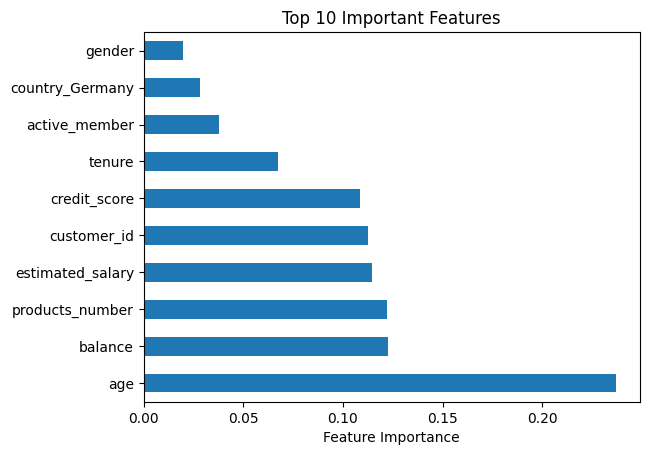

In [ ]:
importances = pd.Series(rf_balanced.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.xlabel("Feature Importance")
plt.show()

In [ ]:
n_trees = [10, 50, 100, 150, 200, 300, 400, 500]
accuracies = []

for n in n_trees:
    rf = RandomForestClassifier(
        n_estimators=n,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"{n} Trees → Accuracy: {acc:.4f}")

10 Trees → Accuracy: 0.8486
50 Trees → Accuracy: 0.8583
100 Trees → Accuracy: 0.8600
100 Trees → Accuracy: 0.8600
150 Trees → Accuracy: 0.8597
150 Trees → Accuracy: 0.8597
200 Trees → Accuracy: 0.8597
200 Trees → Accuracy: 0.8597
300 Trees → Accuracy: 0.8604
300 Trees → Accuracy: 0.8604
400 Trees → Accuracy: 0.8590
400 Trees → Accuracy: 0.8590
500 Trees → Accuracy: 0.8586
500 Trees → Accuracy: 0.8586


In [ ]:
best_n = n_trees[np.argmax(accuracies)]
best_acc = max(accuracies)
print(f"Best Accuracy: {best_acc:.4f} at {best_n} Trees ")

Best Accuracy: 0.8604 at 300 Trees 


In [ ]:
plt.plot(n_trees, accuracies, marker='o', linestyle='--')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Trees")
plt.grid(True)
plt.show()

In [ ]:
rf_final = RandomForestClassifier(
    n_estimators=best_n,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Fitting 3 folds for each of 216 candidates, totalling 648 fits


In [ ]:
#OOB error:
rf_oob = RandomForestClassifier(
    n_estimators=best_n,
    class_weight='balanced',
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf_oob.fit(X_train, y_train)
print("\nOOB Score (Out-of-Bag Estimate):", rf_oob.oob_score_)



OOB Score (Out-of-Bag Estimate): 0.8594249201277955


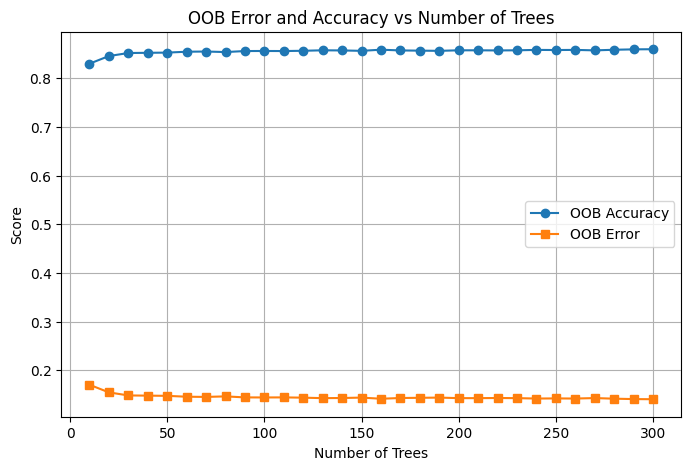

In [ ]:


X = X_train
y = y_train

oob_error = []
oob_accuracy = []
n_estimators_range = range(10, 310, 10)

for n in n_estimators_range:
    rf = RandomForestClassifier(
        n_estimators=n,
        oob_score=True,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X, y)
    oob_accuracy.append(rf.oob_score_)
    oob_error.append(1 - rf.oob_score_)

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_range, oob_accuracy, label='OOB Accuracy', marker='o')
plt.plot(n_estimators_range, oob_error, label='OOB Error', marker='s')
plt.xlabel("Number of Trees")
plt.ylabel("Score")
plt.title("OOB Error and Accuracy vs Number of Trees")
plt.legend()
plt.grid(True)
plt.show()

<Figure size 800x600 with 0 Axes>

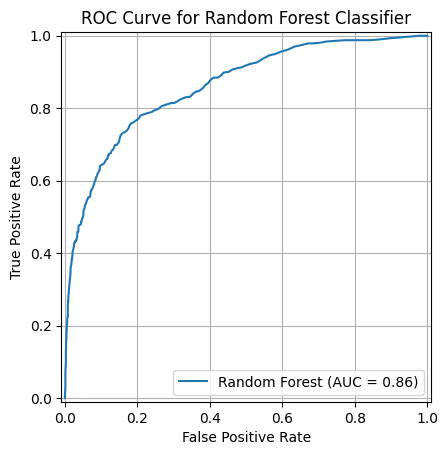


AUC Score: 0.8603


In [ ]:

from sklearn.metrics import roc_curve, auc, RocCurveDisplay

y_prob = rf_final.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="Random Forest").plot()
plt.title("ROC Curve for Random Forest Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.show()

print(f"\nAUC Score: {roc_auc:.4f}")


In [ ]:

import joblib

joblib.dump(rf_final, "random_forest_final_model.pkl")
print("\nModel saved as 'random_forest_final_model.pkl'")

loaded_model = joblib.load("random_forest_final_model.pkl")
y_loaded_pred = loaded_model.predict(X_test)
print("\nLoaded Model Accuracy:", accuracy_score(y_test, y_loaded_pred))


In [ ]:
print(f"Best Number of Trees: {best_n}")
print(f"Base Model Accuracy: {best_acc:.4f}")
print(f"Optimized Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"OOB Score: {rf_oob.oob_score_:.4f}")


Best Number of Trees: 300
Base Model Accuracy: 0.8604
Optimized Model Accuracy: 0.8586
OOB Score: 0.8594


In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

for i, tree in enumerate(rf_final.estimators_[:3]):
    plt.figure(figsize=(20, 20))
    plot_tree(
        tree,
        feature_names=X_train.columns,
        class_names=['No Churn', 'Churn'],
        filled=True,
        rounded=True,
        fontsize=8
    )
    plt.title(f"Decision Tree {i+1} from Random Forest ({best_n} Trees)")
    plt.show()

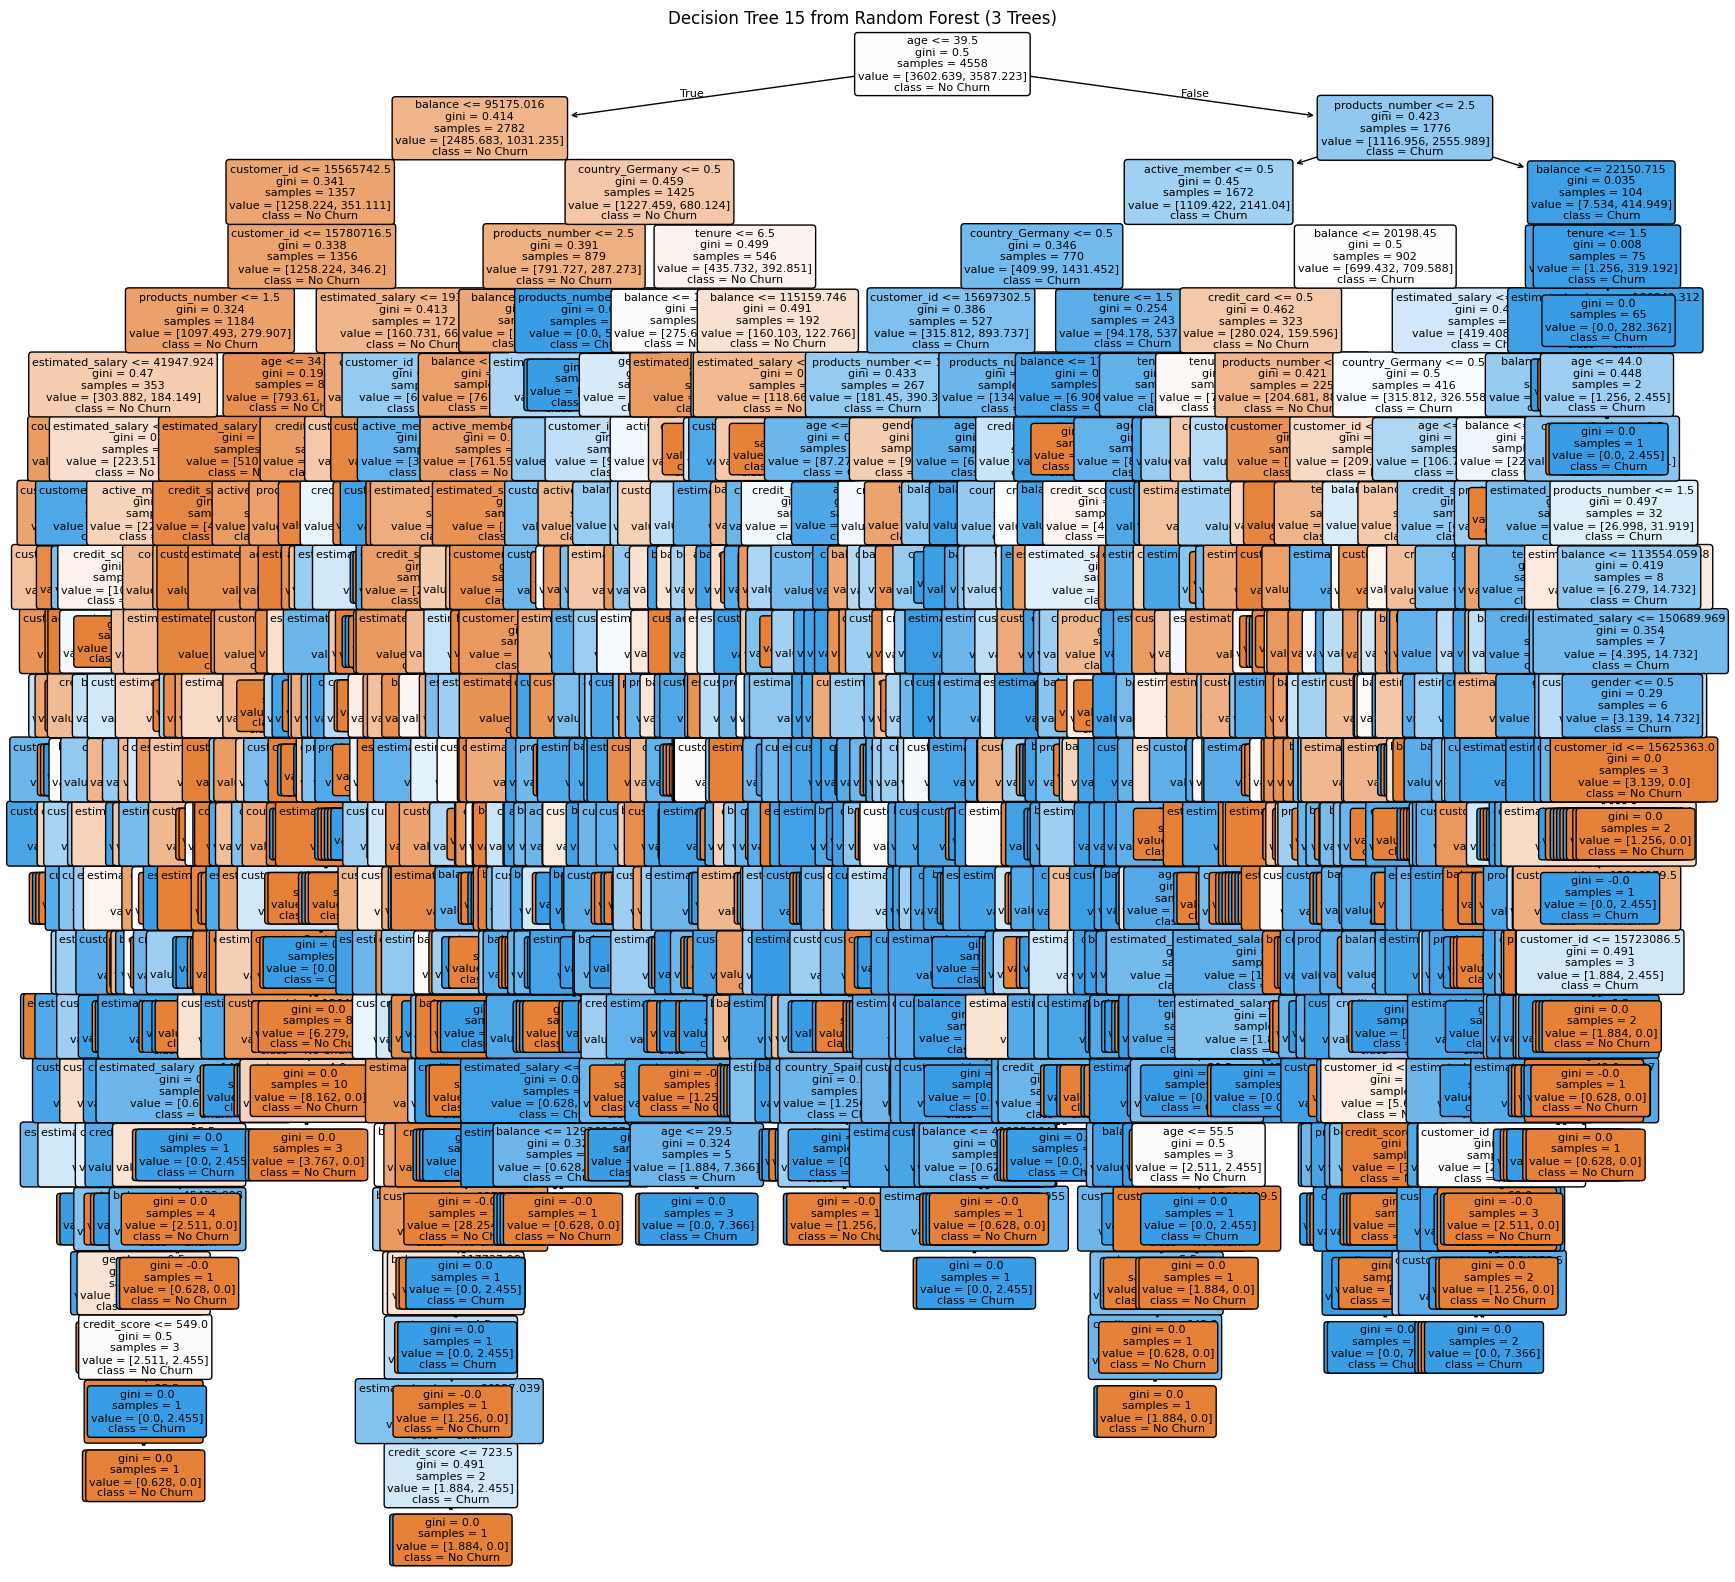

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 20))
plot_tree(
    rf_final.estimators_[14],
    feature_names=X_train.columns,
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title(f"Decision Tree 15 from Random Forest ({3} Trees)")
plt.show()